In [2]:
import numpy as np
import math as math
import matplotlib.pyplot as plt

# Mass calculations with list of measured diameters of 49-53 um

In [4]:
##Now to do mass calculations. D=m/v so Density*Volume = Mass
density_ethanol = 789 ##units are kg/m^3

In [5]:
##tryna see if i can do the above with an array of radii
##these diameters are real measurements that Isabelle did with her code. they very closely match my manual measurements. 
##These diameters are recorded in notion at this link: https://www.notion.so/moorelab/30-June-222c5d00acc280e19045c09c4efb826d

diameter_microns_measured=np.array([49.866493,52.0346,54.92541,52.0346,54.20271,53.118656,52.0346,52.0346,49.866493,54.20271,53.84136,54.20271,53.84136,53.118356])

##diameter to radii
radius_microns_measured= (diameter_microns_measured)/2 

##volume in cubic microns
drop_volume_cubic_microns_measured= 4/3*math.pi*(radius_microns_measured)**3 

##volume converted to cubic meters
drop_volume_cubic_meters_measured=drop_volume_cubic_microns_measured/(1*10**18) 

##mass in kg
drop_mass_kg_measured = density_ethanol * drop_volume_cubic_meters_measured 
print('Drop mass in kilograms', drop_mass_kg_measured)

##converts kg mass to ng
drop_mass_ng_measured = drop_mass_kg_measured * (1*10**12)  
print('Drop mass in nanograms', drop_mass_ng_measured)


Drop mass in kilograms [5.12273753e-11 5.82039269e-11 6.84534826e-11 5.82039269e-11
 6.57867797e-11 6.19179914e-11 5.82039269e-11 5.82039269e-11
 5.12273753e-11 6.57867797e-11 6.44798012e-11 6.57867797e-11
 6.44798012e-11 6.19169423e-11]
Drop mass in nanograms [51.22737526 58.20392692 68.4534826  58.20392692 65.78677966 61.91799142
 58.20392692 58.20392692 51.22737526 65.78677966 64.47980117 65.78677966
 64.47980117 61.91694234]


In [6]:
##converting radius_microns_measured from microns to meters
radius_meters_measured = radius_microns_measured/(1*10**6)
print(radius_meters_measured, ' Radius in meters')

[2.49332465e-05 2.60173000e-05 2.74627050e-05 2.60173000e-05
 2.71013550e-05 2.65593280e-05 2.60173000e-05 2.60173000e-05
 2.49332465e-05 2.71013550e-05 2.69206800e-05 2.71013550e-05
 2.69206800e-05 2.65591780e-05]  Radius in meters


# Charge calculations using Rayleigh limit

In [8]:
##if we use the Rayleigh limit instead of approximating to a conducting sphere
##Q_rayleigh=8*pi*sqrt(epsilon*gamma*r^3)

epsilon = 8.854*10**-12 ##Epsilon is the permitivity of free space with units of F/m
gamma = 0.02197 #N/m surface tension of ethanol
Q_rayleigh_range=8*math.pi*(epsilon*gamma*radius_meters_measured**3)**0.5 #
print(Q_rayleigh_range, 'Coulombs')

##converting to elementary charges
charges_rayleigh_range = Q_rayleigh_range*(6.242*10**18) ##this is a list bc i vary the diameters
print(charges_rayleigh_range, 'elementary charges')


[1.38004387e-12 1.47101799e-12 1.59528990e-12 1.47101799e-12
 1.56390783e-12 1.51722598e-12 1.47101799e-12 1.47101799e-12
 1.38004387e-12 1.56390783e-12 1.54829491e-12 1.56390783e-12
 1.54829491e-12 1.51721313e-12] Coulombs
[8614233.84876593 9182094.29485715 9957799.53402556 9182094.29485715
 9761912.68658724 9470524.56431352 9182094.29485715 9182094.29485715
 8614233.84876593 9761912.68658724 9664456.81644313 9761912.68658724
 9664456.81644313 9470444.333932  ] elementary charges


# Q/m calculations using Rayleigh limit
The below finds a Q/m max of 0.0269395780069957 C/kg and a Q/m min of 0.023304729518441897 C/kg by varying measured diameters from 49-53 um and using the rayleigh limit

In [10]:
#charge to mass ratio using rayleigh limit

Q_m_rayleigh = Q_rayleigh_range/drop_mass_kg_measured
print(Q_m_rayleigh, 'C/kg using Rayleigh limit')


print('Q/m maximum', max(Q_m_rayleigh) , 'C/kg')
print('Q/m minimum', min(Q_m_rayleigh), 'C/kg')

[0.02693958 0.02527352 0.02330473 0.02527352 0.02377237 0.0245038
 0.02527352 0.02527352 0.02693958 0.02377237 0.02401209 0.02377237
 0.02401209 0.02450401] C/kg using Rayleigh limit
Q/m maximum 0.0269395780069957 C/kg
Q/m minimum 0.023304729518441897 C/kg


# Trap stability region for 4.4 mm trap radius

In [12]:
## ganna try to make an array of previous freq & RF voltages that I have been able to trap at in my old PT 
##so i can see where they lie in terms of theory

### 1Khz, 300V 
#130 Hz, 300V, 
#160Hz, 300V   
#155Hz, 300V
#300Hz, 300V
PT_freq_list = np.array([130, 155, 160, 300])
PT_volts_list = np.array([300, 300, 300, 300])

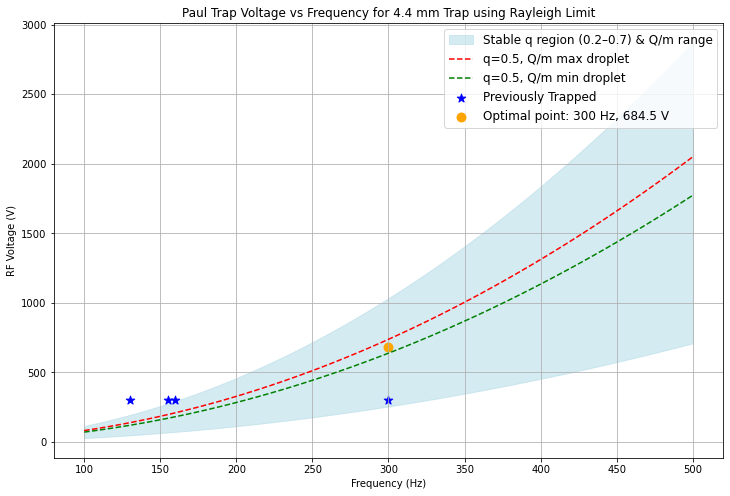

In [13]:

## Parameters 
r0 = 4.4e-3  # Trap radius (m)
f = np.linspace(100,500)  # Frequencies in Hz

## Droplet Q/m measured diameter range of 49-53 µm ethanol drops

Q_m_min = 0.023304729518441897 # C/kg
Q_m_max = 0.0269395780069957 # C/kg


## Stability parameter q 
q_low = 0.2
q_nom = 0.5
q_high = 0.7

## RF voltage calculation
def V_RF(Q_m, q, f):
    return (q * r0**2 * (2 * np.pi * f)**2) / (2 * Q_m)

## Voltages for full stability envelope
V_low = V_RF(Q_m_max, q_low, f)
V_high = V_RF(Q_m_min, q_high, f)

##  Voltages for nominal q lines
V_nom_min = V_RF(Q_m_min, q_nom, f)
V_nom_max = V_RF(Q_m_max, q_nom, f)

## Optimal operating point
f_opt = 300  # Hz
Q_m_opt = (Q_m_min + Q_m_max)/2  # midpoint Q/m
q_opt = 0.5
V_opt = V_RF(Q_m_opt, q_opt, f_opt)

plt.figure(figsize=(12,8))
plt.fill_between(f, V_low, V_high, color='lightblue', alpha=0.5, label='Stable q region (0.2–0.7) & Q/m range')
plt.plot(f, V_nom_min, 'r--', label='q=0.5, Q/m max droplet')
plt.plot(f, V_nom_max, 'g--', label='q=0.5, Q/m min droplet')


plt.scatter(PT_freq_list,PT_volts_list,label='Previously Trapped',alpha=1, s=80 ,marker='*',color='blue')

plt.scatter(f_opt, V_opt, color='orange', s=80, label=f'Optimal point: {f_opt} Hz, {V_opt:.1f} V')
plt.xlabel('Frequency (Hz)')
plt.ylabel('RF Voltage (V)')
#plt.ylim((0,200))
plt.title('Paul Trap Voltage vs Frequency for 4.4 mm Trap using Rayleigh Limit')

plt.rcParams.update({'font.size': 12})
plt.legend()
plt.grid(True)
plt.show()


# Trap radius vs Freq given min and max Q/m using Rayleigh limit

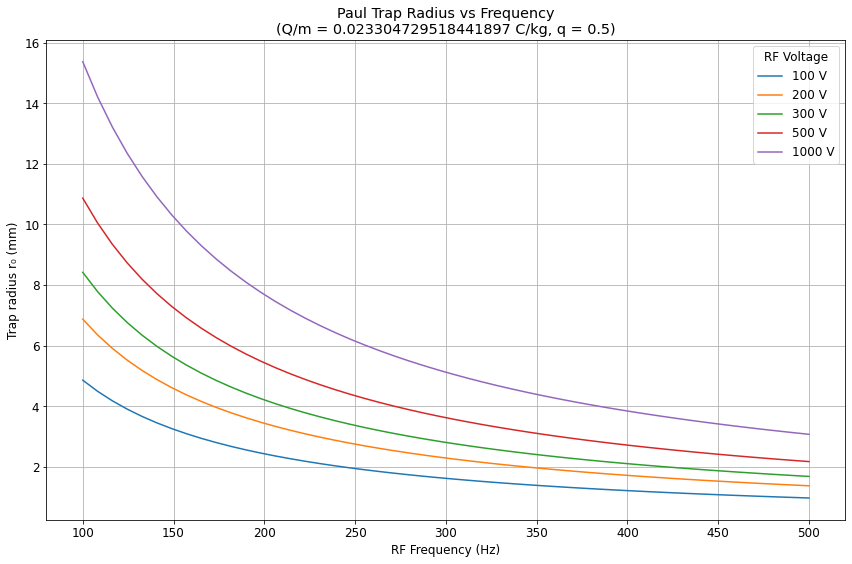

In [15]:


# Fixed parameters
#Q_m_rayleigh = Q_rayleigh_range/drop_mass_kg_measured 
Q_m_rayleigh_min = 0.023304729518441897 # C/kg 
q = 0.5     # Mathieu stability parameter (typical)
freq = np.linspace(100, 500)  # Hz

# RF voltages to compare
voltages = [100, 200, 300, 500, 1000]  # volts


# Trap radius formula is  r0 = sqrt( 2(Q/m)V / ( q (2πf)^2 ) )
def trap_radius(V, f):
    return np.sqrt((2 * Q_m_rayleigh_min * V) / (q * (2*np.pi*f)**2))

plt.figure(figsize=(12,8))

for V in voltages:
    r0 = trap_radius(V, freq)
    plt.plot(freq, r0*1e3, label=f"{V} V")  # convert to mm

plt_2=plt
plt.xlabel("RF Frequency (Hz)")
plt.ylabel("Trap radius r₀ (mm)")
plt.title("Paul Trap Radius vs Frequency\n(Q/m = 0.023304729518441897 C/kg, q = 0.5)")
plt.grid(True)
plt.legend(title="RF Voltage")

plt.tight_layout()
#plt.show()


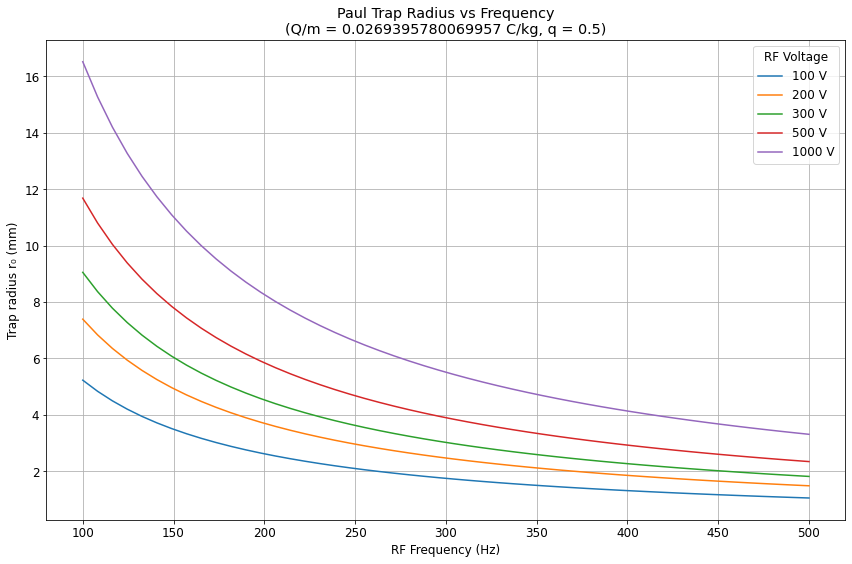

In [16]:
# Fixed parameters
#Q_m_rayleigh = Q_rayleigh_range/drop_mass_kg_measured 
Q_m_rayleigh_max = 0.0269395780069957 # C/kg 
q = 0.5     # Mathieu stability parameter (typical)
freq = np.linspace(100, 500)  # Hz

# RF voltages to compare
voltages = [100, 200, 300, 500, 1000]  # volts


# Trap radius formula is  r0 = sqrt( 2(Q/m)V / ( q (2πf)^2 ) )
def trap_radius(V, f):
    return np.sqrt((2 * Q_m_rayleigh_max * V) / (q * (2*np.pi*f)**2))

plt.figure(figsize=(12,8))

for V in voltages:
    r0 = trap_radius(V, freq)
    plt.plot(freq, r0*1e3, label=f"{V} V")  # convert to mm


plt.xlabel("RF Frequency (Hz)")
plt.ylabel("Trap radius r₀ (mm)")
plt.title("Paul Trap Radius vs Frequency\n(Q/m = 0.0269395780069957 C/kg, q = 0.5)")
plt.grid(True)
plt.legend(title="RF Voltage")

plt.tight_layout()
plt.show()


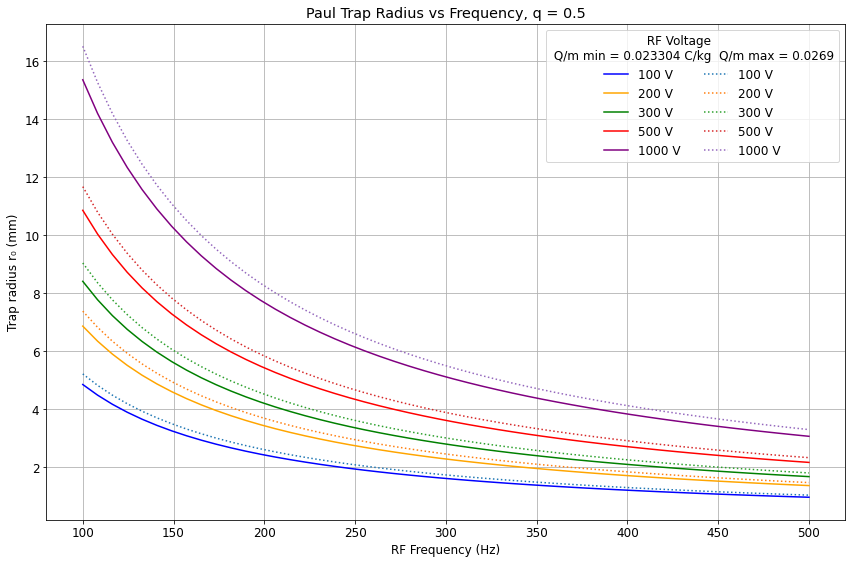

In [17]:
## Fixed parameters
Q_m_min = 0.023304729518441897 # C/kg 
q = 0.5     # Mathieu stability parameter (typical)
freq = np.linspace(100, 500)  # Hz

## RF voltages to compare
voltages = [100, 200, 300, 500, 1000]  # RF Drive voltage (aka voltage on the rods)
colors = ['blue','orange','green', 'red', 'purple'] 


## Trap radius formula is  r0 = sqrt( 2(Q/m)V / ( q (2πf)^2 ) )
def trap_radius(V, f):
    return np.sqrt((2 * Q_m_min * V) / (q * (2*np.pi*f)**2))

plt.figure(figsize=(12,8))

for i in range(0,5):
    V = voltages[i]
    r0 = trap_radius(V, freq)
    plt.plot(freq, r0*1e3, label=f"{V} V",color=colors[i])  # convert to mm


#second plots
Q_m_max = 0.0269395780069957 # C/kg 

# Trap radius formula is  r0 = sqrt( 2(Q/m)V / ( q (2πf)^2 ) )
def trap_radius(V, f):
    return np.sqrt((2 * Q_m_max * V) / (q * (2*np.pi*f)**2))

for V in voltages:
    r0 = trap_radius(V, freq)
    plt.plot(freq, r0*1e3, label=f"{V} V", alpha =1 , linestyle = 'dotted')  # convert to mm


plt.xlabel("RF Frequency (Hz)")
plt.ylabel("Trap radius r₀ (mm)")
plt.title("Paul Trap Radius vs Frequency, q = 0.5")
plt.grid(True)
plt.legend(title='                         RF Voltage \n Q/m min = 0.023304 C/kg  Q/m max = 0.0269', ncol=2)

plt.tight_layout()
plt.show()
plt_2.show()

# Paul Trap design map given min and max Q/m using Rayleigh limit

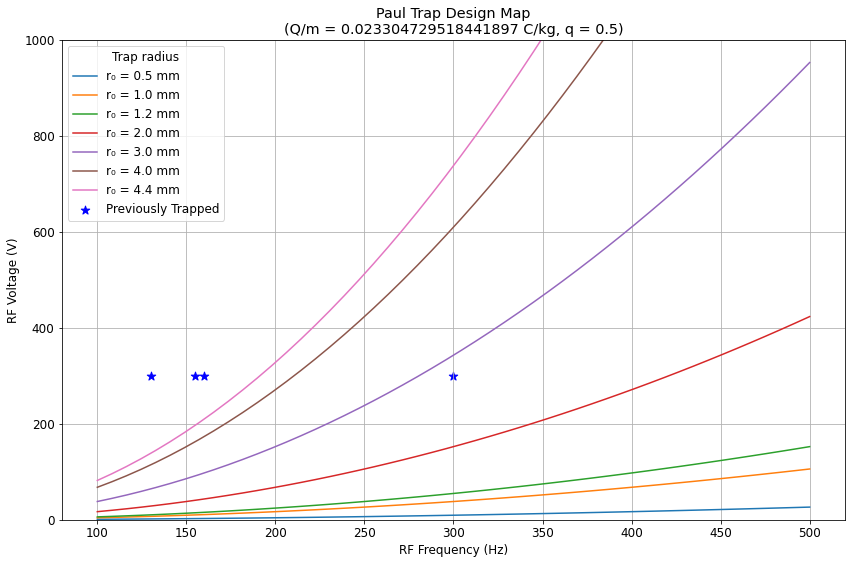

In [19]:

# Fixed parameters
#Q_m_rayleigh = Q_rayleigh_range/drop_mass_kg_measured 
Q_m_rayleigh_min = 0.023304729518441897 # C/kg 
q = 0.5             # Mathieu parameter (typical stable value)

# Frequency range
f = np.linspace(100, 500)  # Hz

# Trap radii to plot (in mm)
radii_mm = [0.5, 1.0, 1.2, 2.0, 3.0, 4.0, 4.4]

# Convert to meters
radii = [r*1e-3 for r in radii_mm]

# Voltage formula:
# V = q * r0^2 * (2πf)^2 / (2 * Q/m)

def V_RF(r0, f):
    return (q * r0**2 * (2*np.pi*f)**2) / (2 * Q_m_rayleigh_min)


plt.figure(figsize=(12,8))

for r0, rmm in zip(radii, radii_mm):
    V = V_RF(r0, f)
    plt.plot(f, V, label=f"r₀ = {rmm} mm")

plt.scatter(PT_freq_list,PT_volts_list,label='Previously Trapped',alpha=1, s=80 ,marker='*',color='blue')
plt.xlabel("RF Frequency (Hz)")
plt.ylabel("RF Voltage (V)")
plt.title("Paul Trap Design Map\n(Q/m = 0.023304729518441897 C/kg, q = 0.5)")
plt.grid(True)
plt.ylim((0,1000))
plt.legend(title="Trap radius")

plt.tight_layout()
plt.show()


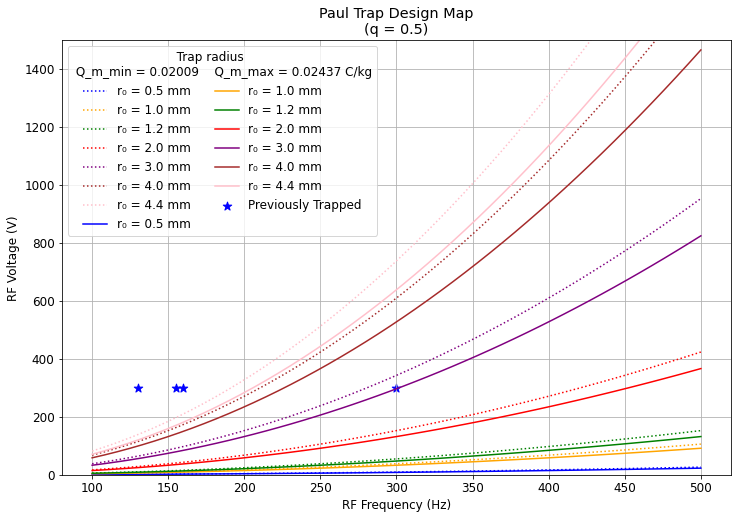

In [20]:
# Fixed parameters
Q_m_min = 0.023304729518441897 # C/kg 
Q_m_max = 0.0269395780069957
q = 0.5             # Mathieu parameter (typical stable value)

# Frequency range
f = np.linspace(100, 500)  # Hz

plt.figure(figsize=(12,8))

# Trap radii to plot (in mm) to compare
radii_mm = [0.5, 1.0, 1.2, 2.0, 3.0, 4.0, 4.4]
colors = ['blue','orange','green', 'red', 'purple', 'brown', 'pink'] 

# Convert to meters
radii = [r*1e-3 for r in radii_mm]

# Voltage formula:
# V = q * r0^2 * (2πf)^2 / (2 * Q/m)

def V_RF(r0, f):
    return (q * r0**2 * (2*np.pi*f)**2) / (2 * Q_m_min)


i=0
for r0, rmm in zip(radii, radii_mm):
    V = V_RF(r0, f)
    plt.plot(f, V, label=f"r₀ = {rmm} mm", color=colors[i], linestyle = 'dotted')
    i=i+1


def V_RF(r0, f):
    return (q * r0**2 * (2*np.pi*f)**2) / (2 * Q_m_max)

i=0
for r0, rmm in zip(radii, radii_mm):
    V = V_RF(r0, f)
    plt.plot(f, V, label=f"r₀ = {rmm} mm", color=colors[i])
    i=i+1
    
#plt.figure(figsize=(12,8))
plt.scatter(PT_freq_list,PT_volts_list,label='Previously Trapped',alpha=1, s=80 ,marker='*',color='blue')
plt.xlabel("RF Frequency (Hz)")
plt.ylabel("RF Voltage (V)")
plt.ylim(0,1500)
plt.title("Paul Trap Design Map\n(q = 0.5)")
plt.grid(True)

plt.rcParams.update({'font.size': 12})
plt.legend(title='                           Trap radius \n Q_m_min = 0.02009    Q_m_max = 0.02437 C/kg',  ncol = 2)


#plt.tight_layout()
plt.show()
